In [ ]:
import importlib
import os
import random

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.nn import BCEWithLogitsLoss
from torch.optim import AdamW
from torch.utils.data import DataLoader

from src import model, utils

importlib.reload(model)
importlib.reload(utils)

from src.model import DeepFakeAudioCNN
from src.utils import (
    DeepFakeAudioDataset,
    MelDeltaExtractor,
    NormalisationStats,
    test,
    train,
)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Constants / default hyperparameters
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_RATE = 16_000  # All audio resampled to this
CLIP_DURATION = 10.0  # Seconds. Shorter clips are zero-padded; longer are centre-cropped.
CLIP_SAMPLES = int(CLIP_DURATION * SAMPLE_RATE)

SEED: int = 42
BATCH_SIZE: int = 32
NUM_WORKERS: int = 4
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME: str = "DeepFakeAudioDetector.pt"


# Set seed to ensure consistency across runs
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()
g.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Number of training samples: 3112
Number of validation samples: 888
Number of testing samples: 447


<Axes: >

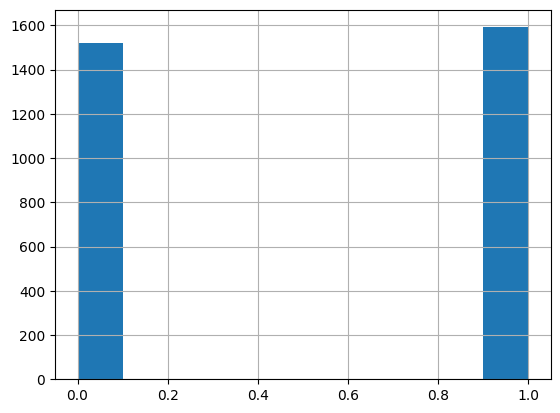

In [3]:
TRAIN_DIR: str = os.path.join("data", "train.csv")
VAL_DIR: str = os.path.join("data", "val.csv")
TEST_DIR: str = os.path.join("data", "test.csv")

train_data_df = pd.read_csv(TRAIN_DIR)
val_data_df = pd.read_csv(VAL_DIR)
test_data_df = pd.read_csv(TEST_DIR)

print(f"Number of training samples: {train_data_df.shape[0]}")
print(f"Number of validation samples: {val_data_df.shape[0]}")
print(f"Number of testing samples: {test_data_df.shape[0]}")

train_data_df["label"].hist()

### Dataset is well balanced so no need for class weighting

In [4]:
# Compute dataset statistics for normalisation
mel_delta_extractor = MelDeltaExtractor()

# ── Normalisation stats ─────────────────────────────────────────
norm_stats_path = os.path.join("data", "norm_stats.pt")

if norm_stats_path and os.path.isfile(norm_stats_path):
    print(f"Loading normalisation stats from {norm_stats_path}")
    norm_stats = NormalisationStats.load(norm_stats_path)
else:
    norm_stats = NormalisationStats.compute_from_dataset(
        csv_path=TRAIN_DIR,
        extractor=mel_delta_extractor,
        clip_samples=CLIP_SAMPLES,
        num_workers=NUM_WORKERS,
    )
    norm_stats.save(norm_stats_path)
    print(f"Normalisation stats saved to {norm_stats_path}")

# ── Datasets ──────────────────────────────────────────────────────────────
train_dataset = DeepFakeAudioDataset(
    csv_path=TRAIN_DIR,
    extractor=mel_delta_extractor,
    clip_samples=CLIP_SAMPLES,
    norm_stats=norm_stats,
    augment=True,  # augmentation ON for training
    sample_rate=SAMPLE_RATE,
)
val_dataset = DeepFakeAudioDataset(
    csv_path=VAL_DIR,
    extractor=mel_delta_extractor,
    clip_samples=CLIP_SAMPLES,
    norm_stats=norm_stats,
    augment=False,  # NO augmentation for val/test
    sample_rate=SAMPLE_RATE,
)
test_dataset = DeepFakeAudioDataset(
    csv_path=TEST_DIR,
    extractor=mel_delta_extractor,
    clip_samples=CLIP_SAMPLES,
    norm_stats=norm_stats,
    augment=False,
    sample_rate=SAMPLE_RATE,
)

# ── DataLoaders ───────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,  # keeps batch norm stable in training
    worker_init_fn=seed_worker,
    generator=g,
    prefetch_factor=2,
    persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=g,
    prefetch_factor=2,
    persistent_workers=(NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=g,
    prefetch_factor=2,
    persistent_workers=(NUM_WORKERS > 0),
)

spectrogram, label, mask = next(iter(train_loader))
# (batch_size, channels, n_mels, time_frames) where time_frames = clip_samples // hop_length + 1
print(f"Spectrogram shape: {spectrogram.shape}")
print(f"Label shape: {label.shape}")  # (batch_size,)
print(f"Mask shape: {mask.shape}")  # (batch_size, time_frames)

print(
    f"\nDataLoaders ready:\n"
    f"  Train: {len(train_dataset):,} samples — {len(train_loader)} batches\n"
    f"  Val:   {len(val_dataset):,} samples  — {len(val_loader)} batches\n"
    f"  Test:  {len(test_dataset):,} samples  — {len(test_loader)} batches\n"
)

Loading normalisation stats from data/norm_stats.pt
Spectrogram shape: torch.Size([32, 3, 80, 1001])
Label shape: torch.Size([32])
Mask shape: torch.Size([32, 1001])

DataLoaders ready:
  Train: 3,112 samples — 97 batches
  Val:   888 samples  — 28 batches
  Test:  447 samples  — 14 batches



In [5]:
model = DeepFakeAudioCNN()

backbone_params = list(model.feature_extractor.parameters())
head_params = list(model.classifier.parameters()) + list(model.pooling.parameters())

optimizer = AdamW(
    [
        {"params": backbone_params, "lr": 1e-4},
        {"params": head_params, "lr": 1e-3},
    ],
    weight_decay=1e-2,
)

criterion = BCEWithLogitsLoss()

output = train(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    DEVICE,
    epochs=50,
    save_path=MODEL_NAME,
)

Epoch 1/50: 100%|██████████| 97/97 [00:13<00:00,  7.23batch/s, Loss=0.2625]


Train Loss: 0.3794 | Val Loss: 0.1928 | Precision: 0.9281 | Recall: 0.9257 | F1-Score: 0.9255
  --> New best model saved to models/DeepFakeAudioDetector.pt


Epoch 2/50: 100%|██████████| 97/97 [00:12<00:00,  7.58batch/s, Loss=0.1279]


Train Loss: 0.1850 | Val Loss: 0.1853 | Precision: 0.9346 | Recall: 0.9302 | F1-Score: 0.9301
  --> New best model saved to models/DeepFakeAudioDetector.pt


Epoch 3/50: 100%|██████████| 97/97 [00:13<00:00,  7.34batch/s, Loss=0.0876]


...

Train Loss: 0.0204 | Val Loss: 0.0367 | Precision: 0.9911 | Recall: 0.9910 | F1-Score: 0.9910


Epoch 18/50: 100%|██████████| 97/97 [00:12<00:00,  7.89batch/s, Loss=0.0003]


Train Loss: 0.0126 | Val Loss: 0.0407 | Precision: 0.9900 | Recall: 0.9899 | F1-Score: 0.9899


Epoch 19/50: 100%|██████████| 97/97 [00:12<00:00,  7.98batch/s, Loss=0.0009]


Train Loss: 0.0074 | Val Loss: 0.0405 | Precision: 0.9900 | Recall: 0.9899 | F1-Score: 0.9899
Early stopping triggered.


Loading model from models/DeepFakeAudioDetector.pt
Test Precision: 0.9911
Test Recall: 0.9911
Test F1-score: 0.9911


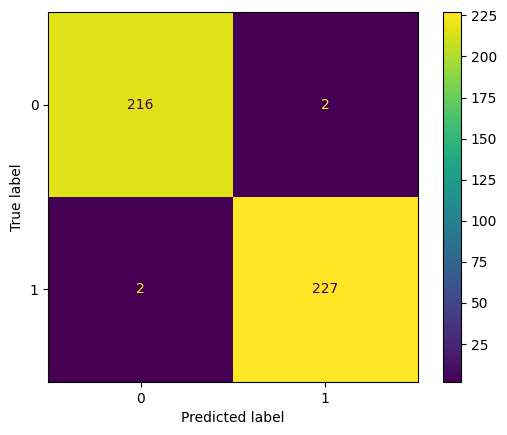

In [ ]:
# Load the model
model = DeepFakeAudioCNN()
weights_path = os.path.join("models", MODEL_NAME)

try:
    print(f"Loading model from {weights_path}")
    state = torch.load(weights_path, map_location=DEVICE)

    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]

    model.load_state_dict(state)
except FileNotFoundError:
    print(f"Model file {weights_path} not found. Please train the model first.")

precision, recall, f1_score, all_labels, all_preds = test(model, test_loader, DEVICE)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1_score:.4f}")

# Plot a confusion matrix for the test set
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
pyplot.show()

In [7]:
# Save the model in half precision
model.half()
half_model_save_path = os.path.join("models", "DeepFakeAudioDetector_half.pt")
torch.save(model.state_dict(), half_model_save_path)

print(f"Half precision model saved to {half_model_save_path}")